# Past the Tipping Point, Not Yet Transformed

**Exploration notebook · China NEV transition · data vintage 2026-07-12**

Central question: *How quickly is China's dominance of new-energy
vehicles in new-vehicle sales translating into the on-road fleet, and
has charging infrastructure kept pace?*

The notebook keeps annual observations, partial-year observations,
registered fleet stock, and charging connectors in separate tables.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.metrics import cagr, growth_contribution, percent_change, ratio, share
from src.scenarios import scenario_table

DATA = ROOT / "data" / "processed"
annual = pd.read_csv(DATA / "china_auto_market_2015_2025.csv")
fleet = pd.read_csv(DATA / "fleet_charging_snapshot.csv")
pulse = pd.read_csv(DATA / "current_market_pulse.csv")
targets = pd.read_csv(DATA / "policy_targets.csv")

print(f"Loaded {len(annual)} complete annual observations: {annual.year.min()}-{annual.year.max()}")

Loaded 11 complete annual observations: 2015-2025


## 1. Basic mathematics

The core calculations are intentionally transparent:

$$\text{NEV share}_t = \frac{\text{NEV sales}_t}{\text{total automobile sales}_t} \times 100$$

$$\text{YoY growth}_t = \left(\frac{x_t}{x_{t-1}} - 1\right) \times 100$$

$$\text{CAGR} = \left(\frac{x_{end}}{x_{start}}\right)^{1/n} - 1$$

A growth contribution above 100% is possible: it means the growing
component more than explains total net growth while another component
contracted.

In [2]:
annual = annual.assign(
    nev_share_total_sales_pct=lambda x: 100 * x.nev_sales_m / x.total_auto_sales_m,
    nev_sales_yoy_pct=lambda x: x.nev_sales_m.pct_change() * 100,
    non_nev_sales_m=lambda x: x.total_auto_sales_m - x.nev_sales_m,
)

display(
    annual[["year", "total_auto_sales_m", "nev_sales_m", "nev_share_total_sales_pct", "nev_sales_yoy_pct"]]
    .round(2)
    .style.format({
        "total_auto_sales_m": "{:.2f}",
        "nev_sales_m": "{:.2f}",
        "nev_share_total_sales_pct": "{:.1f}%",
        "nev_sales_yoy_pct": "{:.1f}%",
    })
)

,year,total_auto_sales_m,nev_sales_m,nev_share_total_sales_pct,nev_sales_yoy_pct
0,2015,24.60,0.33,1.4%,nan%
1,2016,28.03,0.51,1.8%,53.1%
2,2017,28.88,0.78,2.7%,53.2%
3,2018,28.08,1.26,4.5%,61.6%
4,2019,25.77,1.21,4.7%,-4.0%
5,2020,25.31,1.37,5.4%,13.3%
6,2021,26.28,3.52,13.4%,157.6%
7,2022,26.86,6.89,25.6%,95.6%
8,2023,30.09,9.49,31.6%,37.9%
9,2024,31.44,12.87,40.9%,35.5%


## 2. The first results

The 2025 total-sales share (47.9%) and the separately reported domestic
new-sales share (50.8%) use different denominators. The registered fleet
share (12.0%) is a stock measure. Keeping those definitions visible is
part of the analysis, not a footnote added at the end.

In [3]:
y2024 = annual.loc[annual.year == 2024].iloc[0]
y2025 = annual.loc[annual.year == 2025].iloc[0]
f2025 = fleet.loc[fleet.period == "2025-12-31"].iloc[0]

nev_cagr = cagr(annual.iloc[0].nev_sales_m, y2025.nev_sales_m, 10)
total_share = share(y2025.nev_sales_m, y2025.total_auto_sales_m)
fleet_share = share(f2025.nev_stock_m, f2025.auto_stock_m)
domestic_share = pulse.loc[
    (pulse.period == "2025") & (pulse.scope == "domestic_new_vehicle_sales"),
    "nev_share_reported_pct",
].iloc[0]

total_growth = y2025.total_auto_sales_m - y2024.total_auto_sales_m
nev_growth = y2025.nev_sales_m - y2024.nev_sales_m
non_nev_change = (
    y2025.total_auto_sales_m - y2025.nev_sales_m
    - y2024.total_auto_sales_m + y2024.nev_sales_m
)

summary = pd.DataFrame(
    {
        "Result": [
            "NEV sales CAGR, 2015–2025",
            "NEV share of total CAAM sales, 2025",
            "NEV share of domestic new sales, 2025",
            "NEV share of registered fleet, 2025",
            "Domestic-sales flow minus fleet-stock gap",
            "NEV contribution to 2025 net market growth",
            "Change in non-NEV sales, 2024–2025",
        ],
        "Value": [
            f"{nev_cagr:.1f}%",
            f"{total_share:.1f}%",
            f"{domestic_share:.1f}%",
            f"{fleet_share:.1f}%",
            f"{domestic_share - fleet_share:.1f} pp",
            f"{growth_contribution(nev_growth, total_growth):.1f}%",
            f"{non_nev_change:.2f} million",
        ],
    }
)
display(summary)

,Result,Value
0,"NEV sales CAGR, 2015–2025",47.8%
1,"NEV share of total CAAM sales, 2025",47.9%
2,"NEV share of domestic new sales, 2025",50.8%
3,"NEV share of registered fleet, 2025",12.0%
4,Domestic-sales flow minus fleet-stock gap,38.8 pp
5,NEV contribution to 2025 net market growth,122.3%
6,"Change in non-NEV sales, 2024–2025",-0.66 million


**Interpretation.** NEV sales grew at roughly 47.8% per year across the
decade. In 2025 they generated more than all net automobile-market
growth (122.3%) because estimated non-NEV sales fell by 0.66 million.
This is descriptive accounting, not a causal claim.

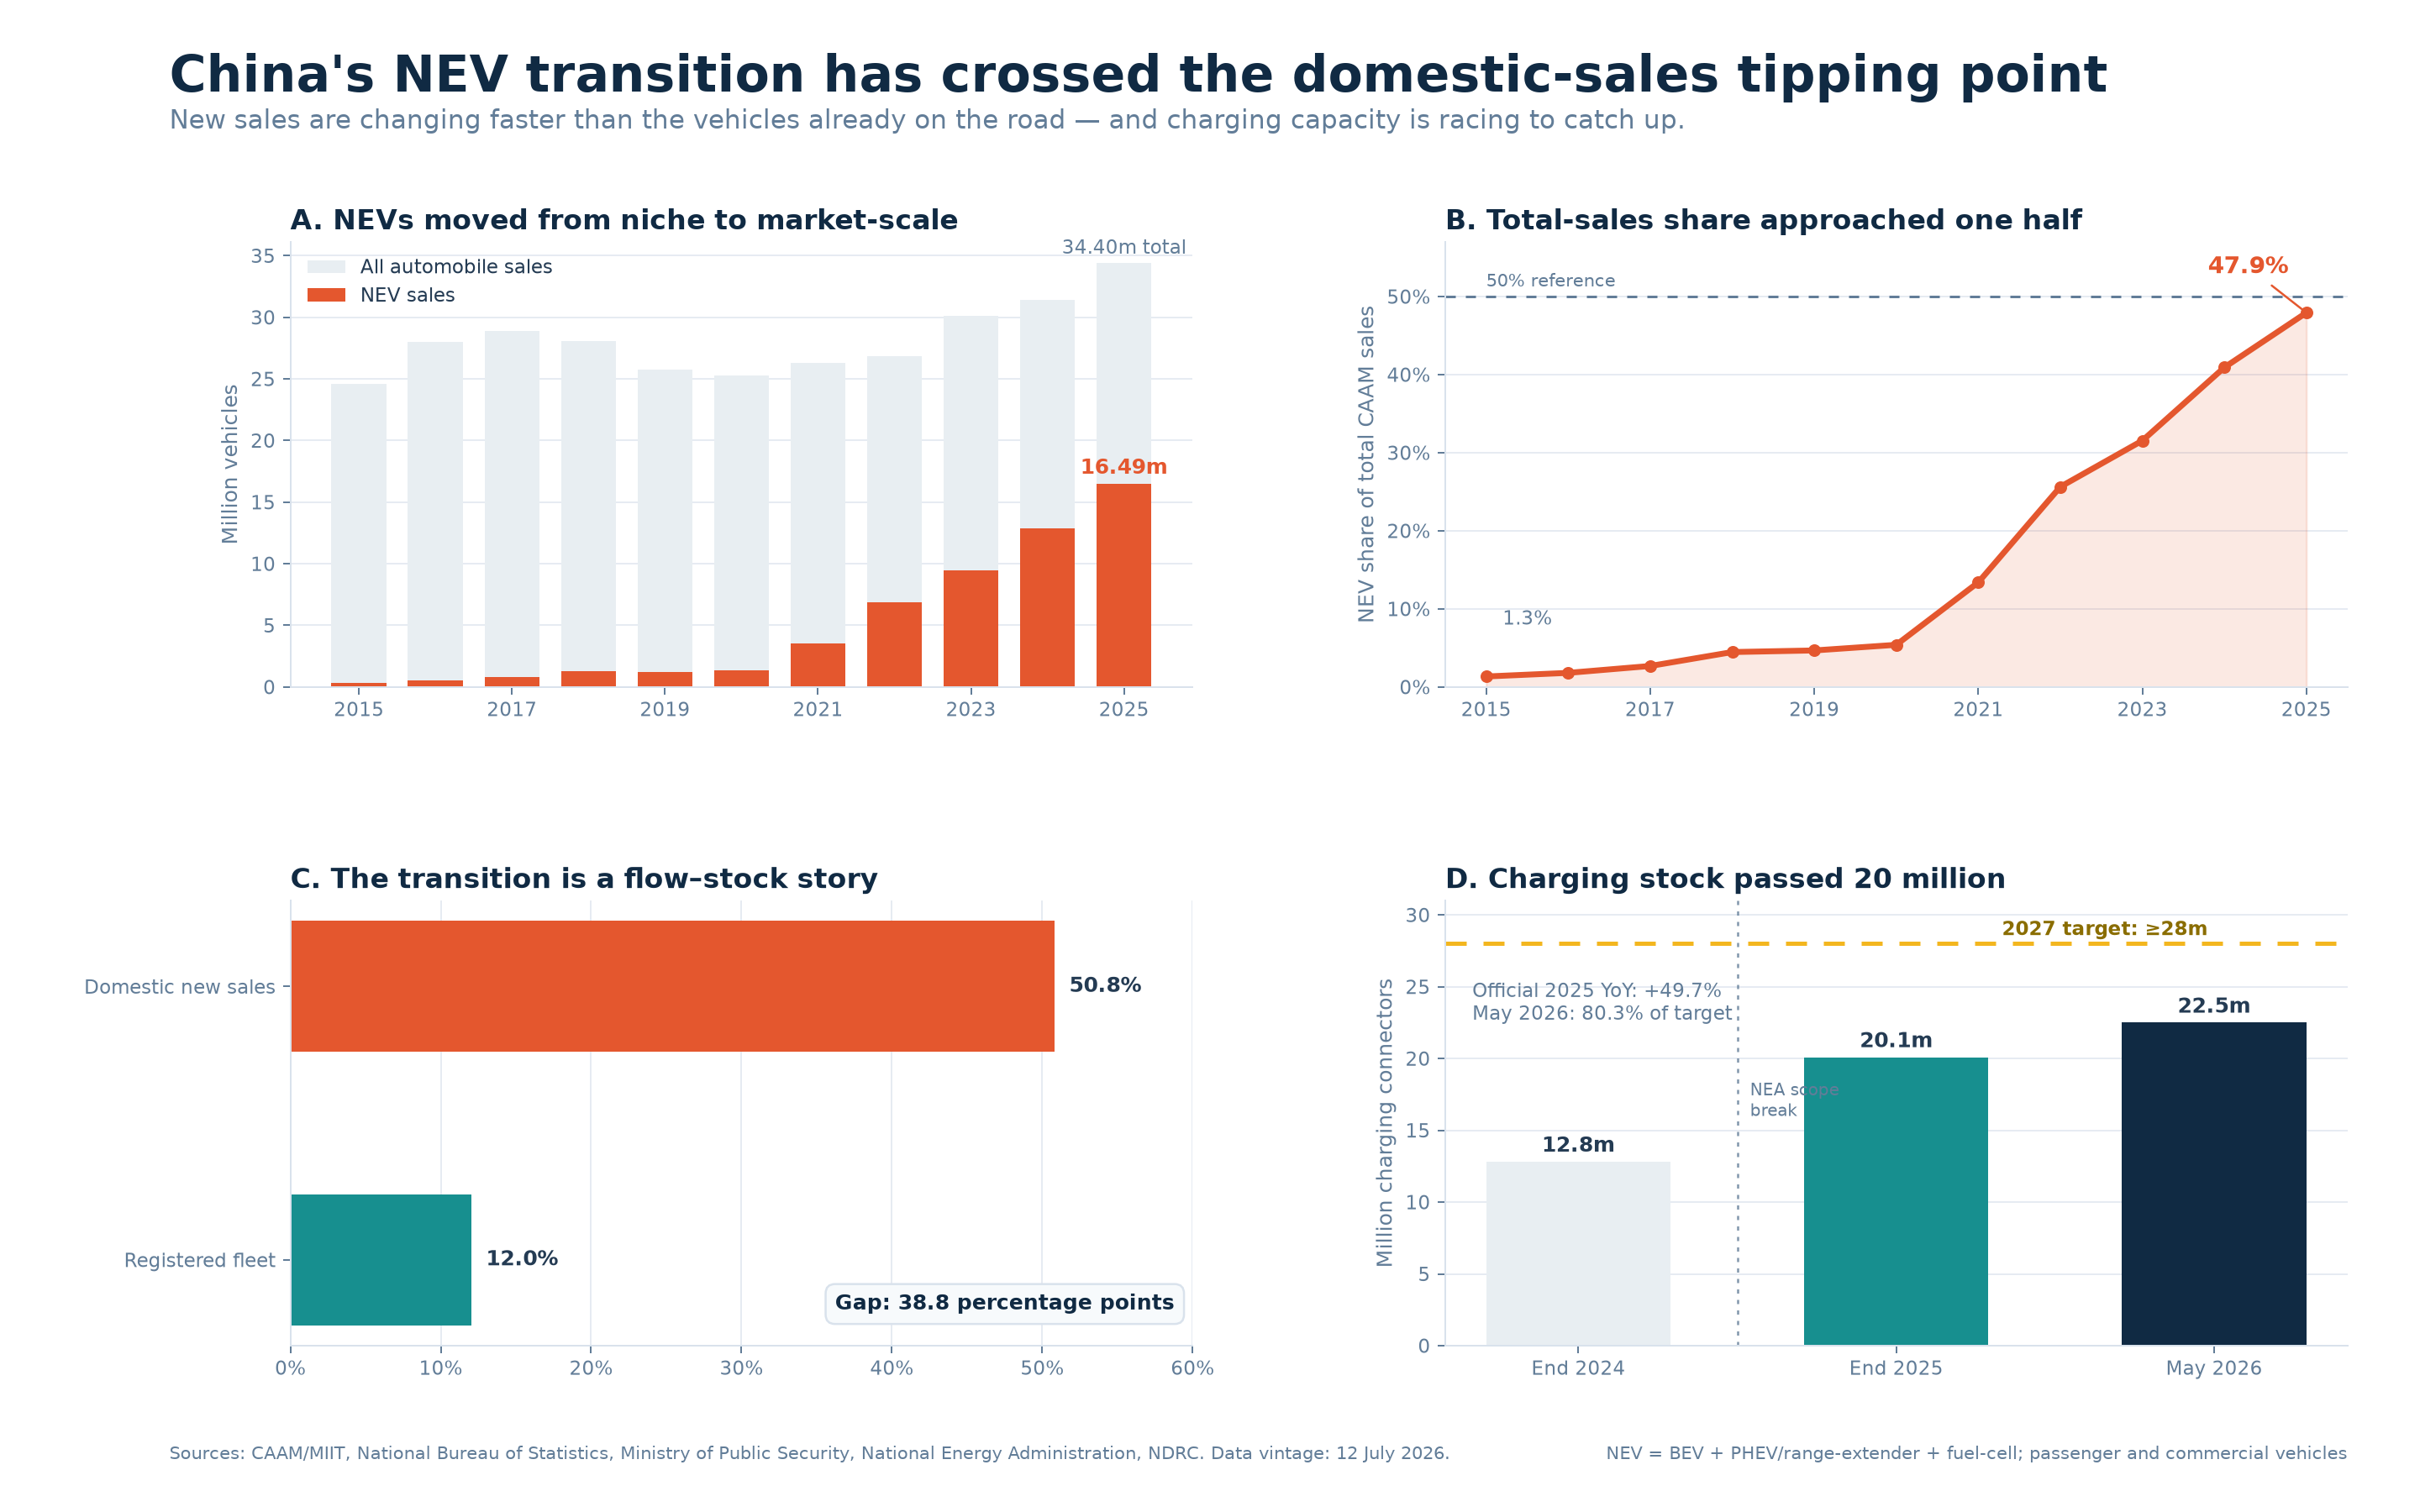

In [4]:
display(Image(filename=str(ROOT / "figures" / "first_look_dashboard.png"), width=1100))

## 3. A bounded scenario, not a confident forecast

A linear extrapolation can exceed 100%, so the scenario uses log-odds:

$$\operatorname{logit}(p_{t+h}) = \operatorname{logit}(p_t) + h g$$

Here $g$ is an explicit annual increment, not an estimated causal
effect. Three values illustrate slower, baseline, and faster paths.

scenario,Baseline,Faster,Slower
year,,,
2025,47.9%,47.9%,47.9%
2026,54.2%,56.6%,51.7%
2027,60.3%,65.0%,55.4%
2028,66.1%,72.5%,59.1%
2029,71.5%,78.9%,62.7%
2030,76.3%,84.1%,66.1%


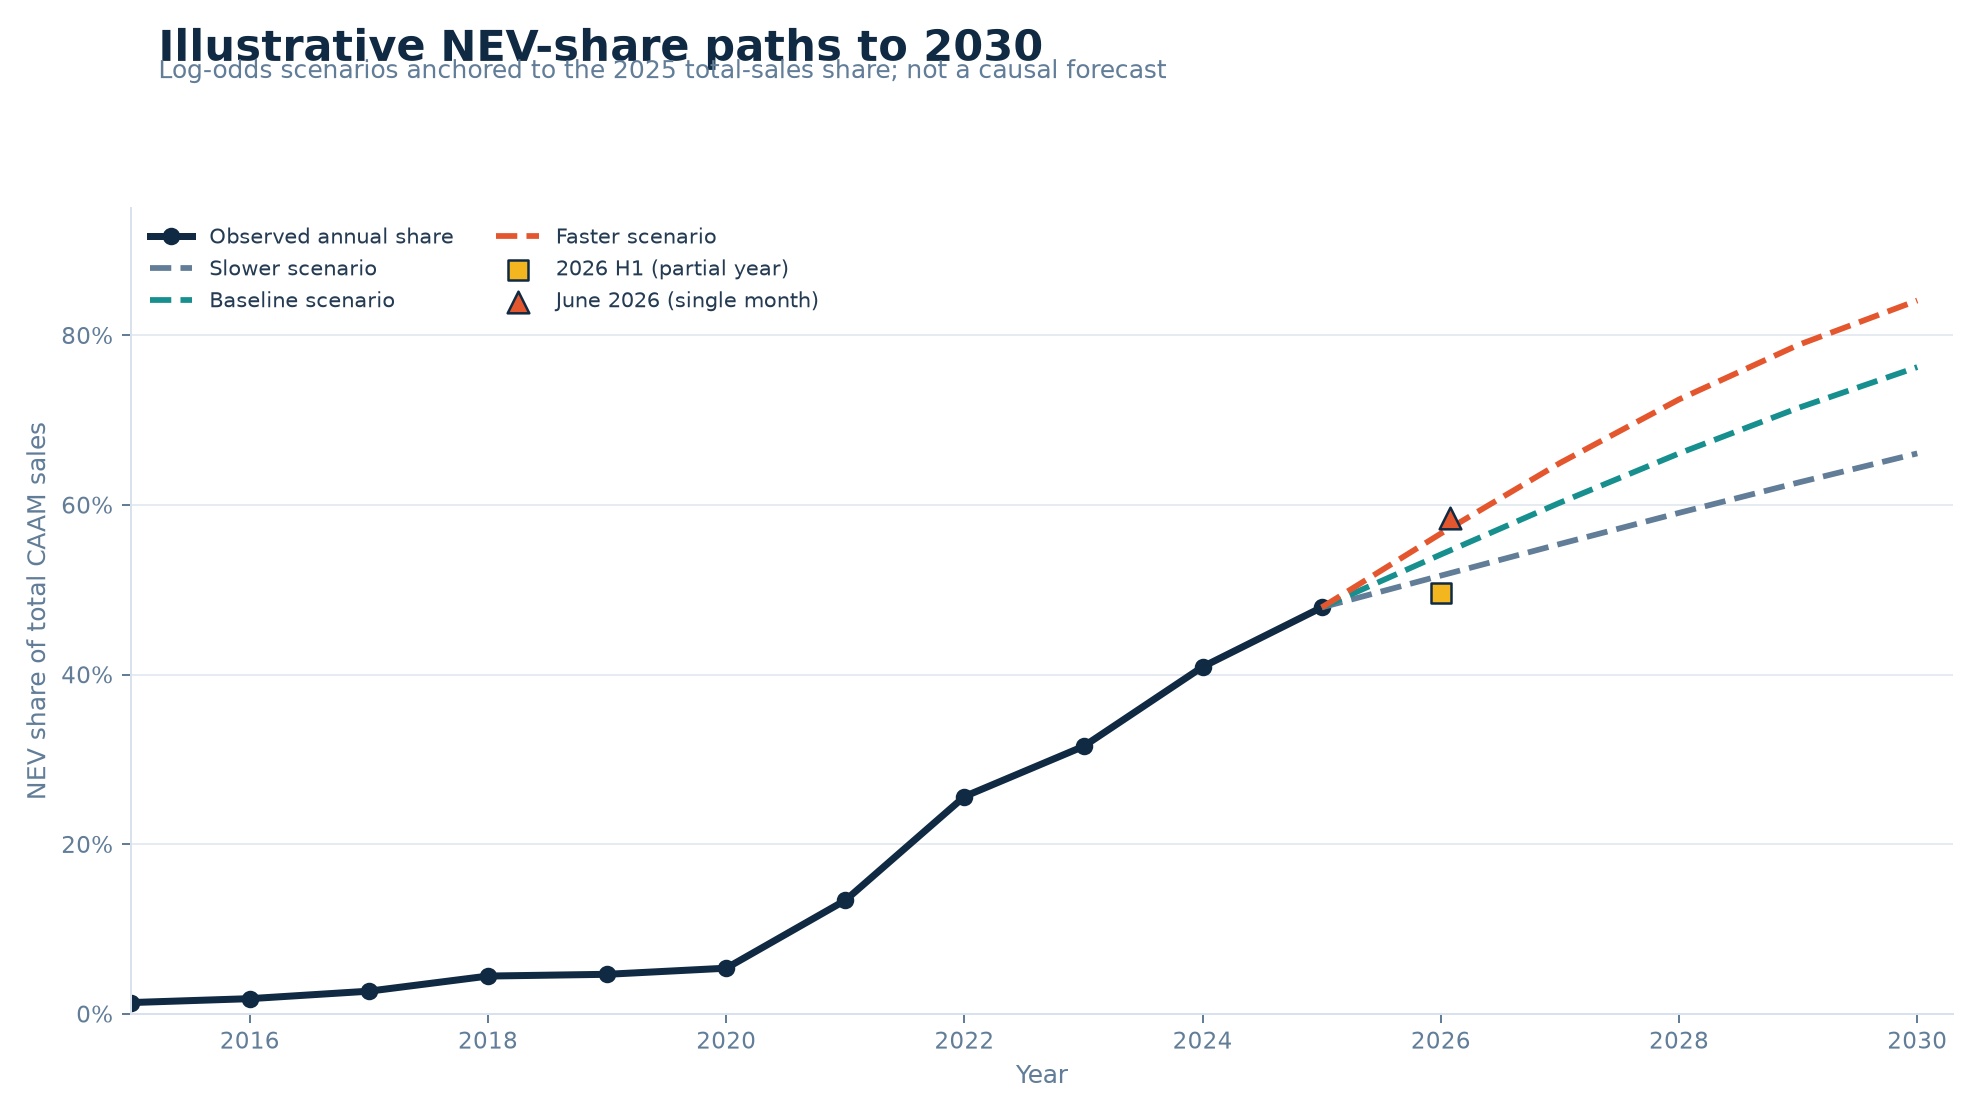

In [5]:
scenarios = scenario_table(
    anchor_year=2025,
    anchor_share=total_share,
    end_year=2030,
    annual_logit_gains={"Slower": 0.15, "Baseline": 0.25, "Faster": 0.35},
)
display(
    scenarios.pivot(index="year", columns="scenario", values="nev_share_pct")
    .round(1)
    .style.format("{:.1f}%")
)
display(Image(filename=str(ROOT / "figures" / "scenario_paths.png"), width=900))

## 4. Powertrain composition and exports

Reported powertrain components are reconciled to annual NEV totals
within published rounding. Exports are enterprise-reported industry
volumes; sales minus exports is labelled as a residual proxy rather
than as a separately observed domestic-retail series.

,year,bev_sales_m,phev_sales_m,bev_share_of_nev_pct,phev_share_of_nev_pct,component_reconciliation_gap_m
0,2020,1.12,0.25,81.57,18.36,0.0
4,2024,7.72,5.14,60.00,39.96,-0.0


,year,total_auto_exports_m,nev_exports_m,nev_share_of_exports_pct,non_export_nev_share_proxy_pct
0,2021,2.02,0.31,15.38,13.24
1,2022,3.11,0.68,21.83,26.14
2,2023,4.91,1.20,24.50,32.93
3,2024,5.86,1.28,21.92,45.28
4,2025,7.10,2.62,36.84,50.82


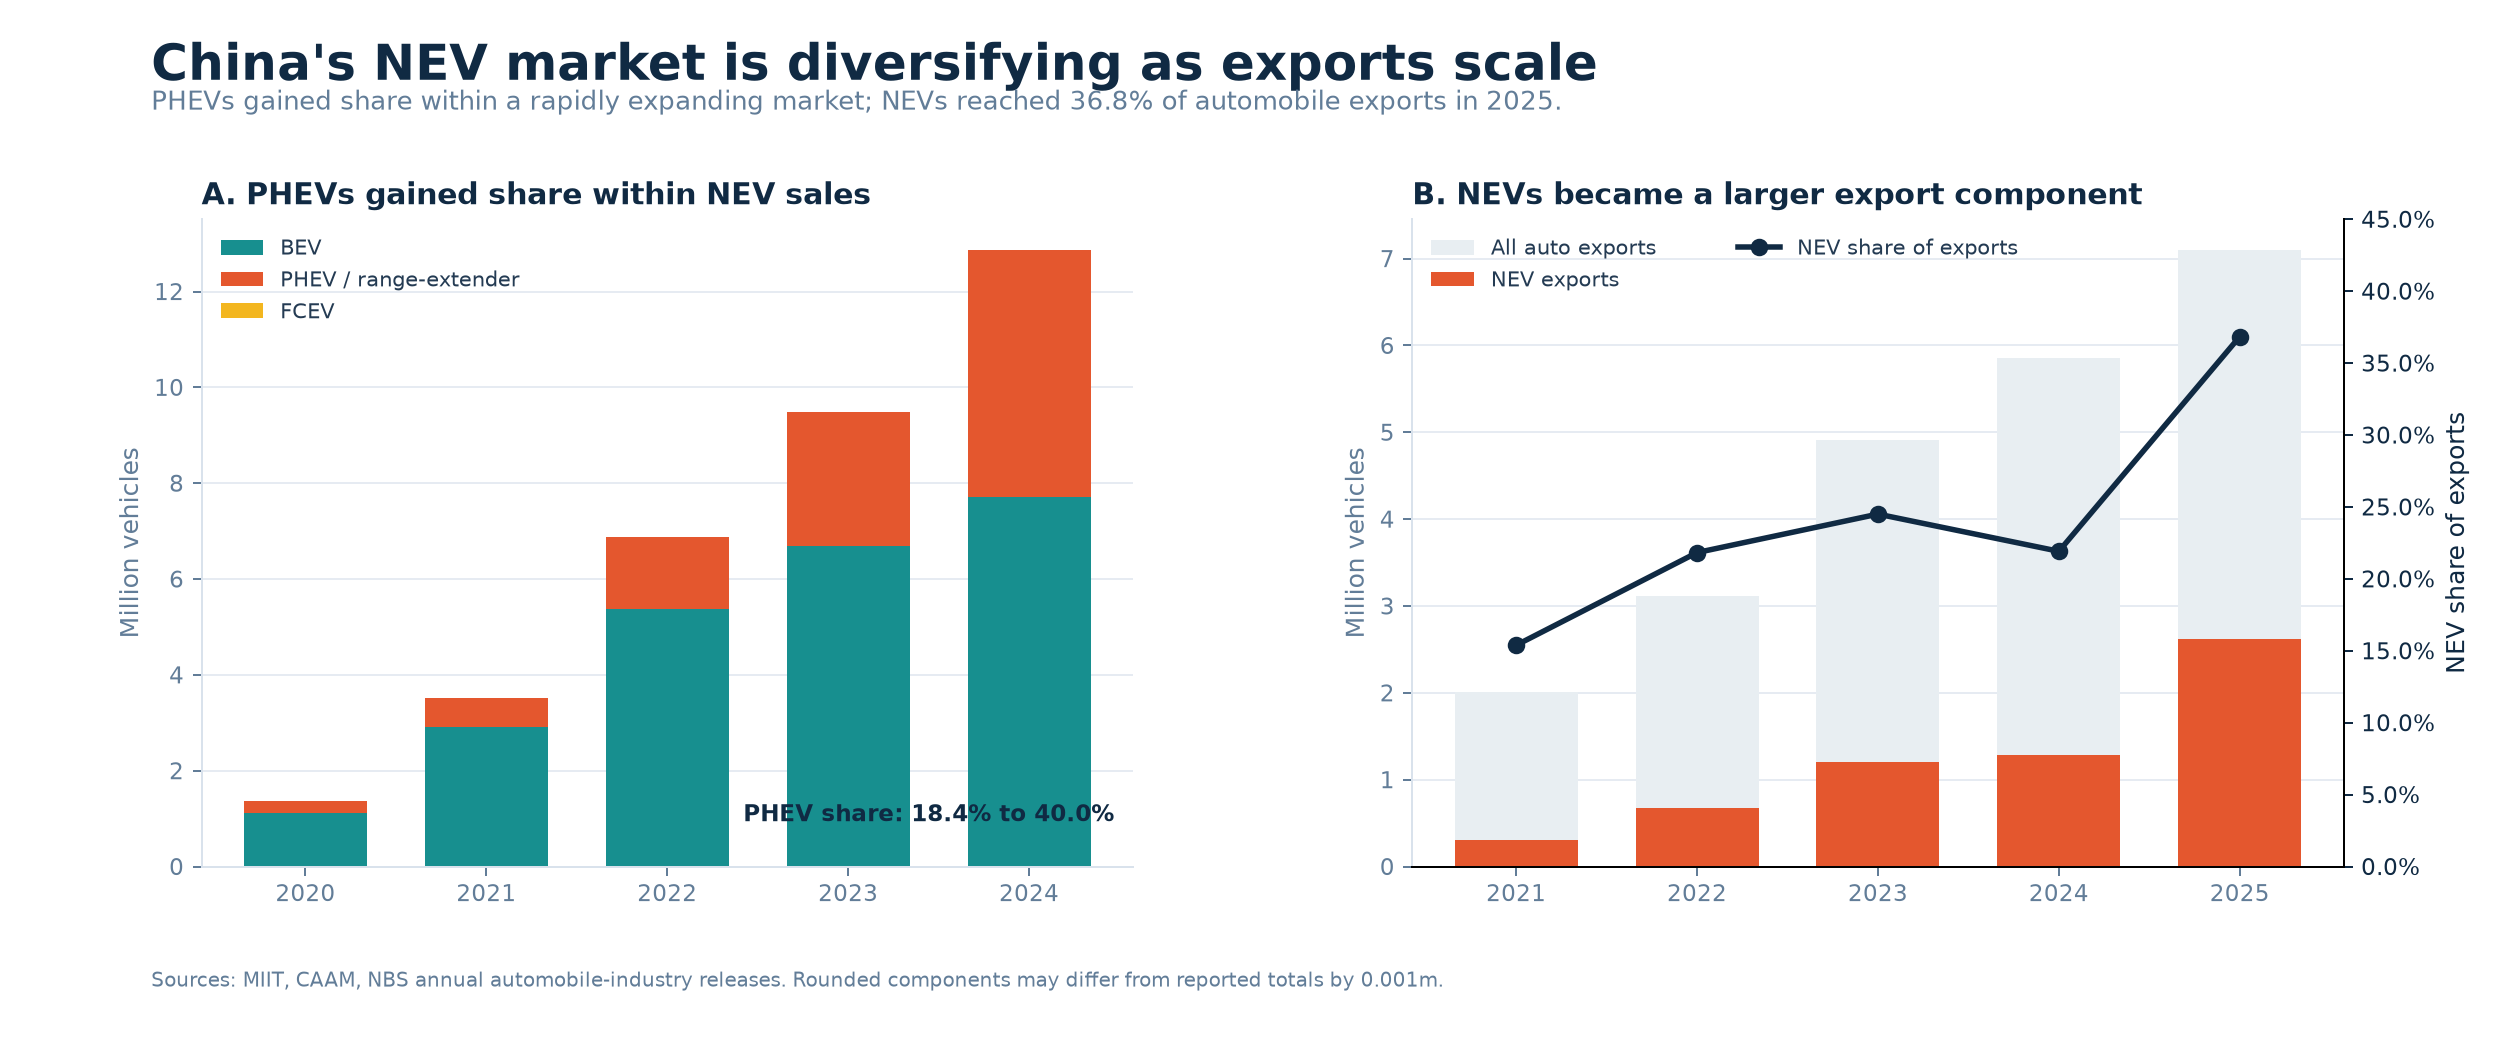

In [6]:
powertrain = pd.read_csv(DATA / "powertrain_mix_metrics.csv")
exports = pd.read_csv(DATA / "export_metrics.csv")

display(
    powertrain.loc[
        powertrain.year.isin([2020, 2024]),
        [
            "year",
            "bev_sales_m",
            "phev_sales_m",
            "bev_share_of_nev_pct",
            "phev_share_of_nev_pct",
            "component_reconciliation_gap_m",
        ],
    ].round(2)
)
display(
    exports[
        [
            "year",
            "total_auto_exports_m",
            "nev_exports_m",
            "nev_share_of_exports_pct",
            "non_export_nev_share_proxy_pct",
        ]
    ].round(2)
)
display(Image(filename=str(ROOT / "figures" / "powertrain_exports.png"), width=1100))

## 5. Fleet-turnover sensitivities and held-out check

The stock-flow model starts from end-2025 registered stock, holds the
domestic-inflow proxy constant, and makes every turnover rate and
retirement-allocation weight explicit. The model output is a
sensitivity calculation, not a registration forecast.

,scenario,year,nev_inflow_share_pct,nev_fleet_share_pct,nev_stock_m,total_auto_stock_m
4,Conservative,2030,68.6,30.7,122.2,398.2
9,Conservative,2035,82.2,50.2,212.2,422.4
14,Baseline,2030,78.3,33.4,130.1,389.8
19,Baseline,2035,92.6,56.7,231.0,407.1
24,Accelerated,2030,85.6,36.5,136.1,373.4
29,Accelerated,2035,97.2,63.3,239.5,378.5


,year,observed_nev_share_pct,predicted_nev_share_pct,absolute_error_pp,train_end_year,annual_logit_gain_fitted
0,2023,31.55,25.58,5.97,2022,0.42
1,2024,40.93,34.39,6.53,2022,0.42
2,2025,47.94,44.43,3.50,2022,0.42


Held-out 2023-2025 MAE: 5.34 percentage points


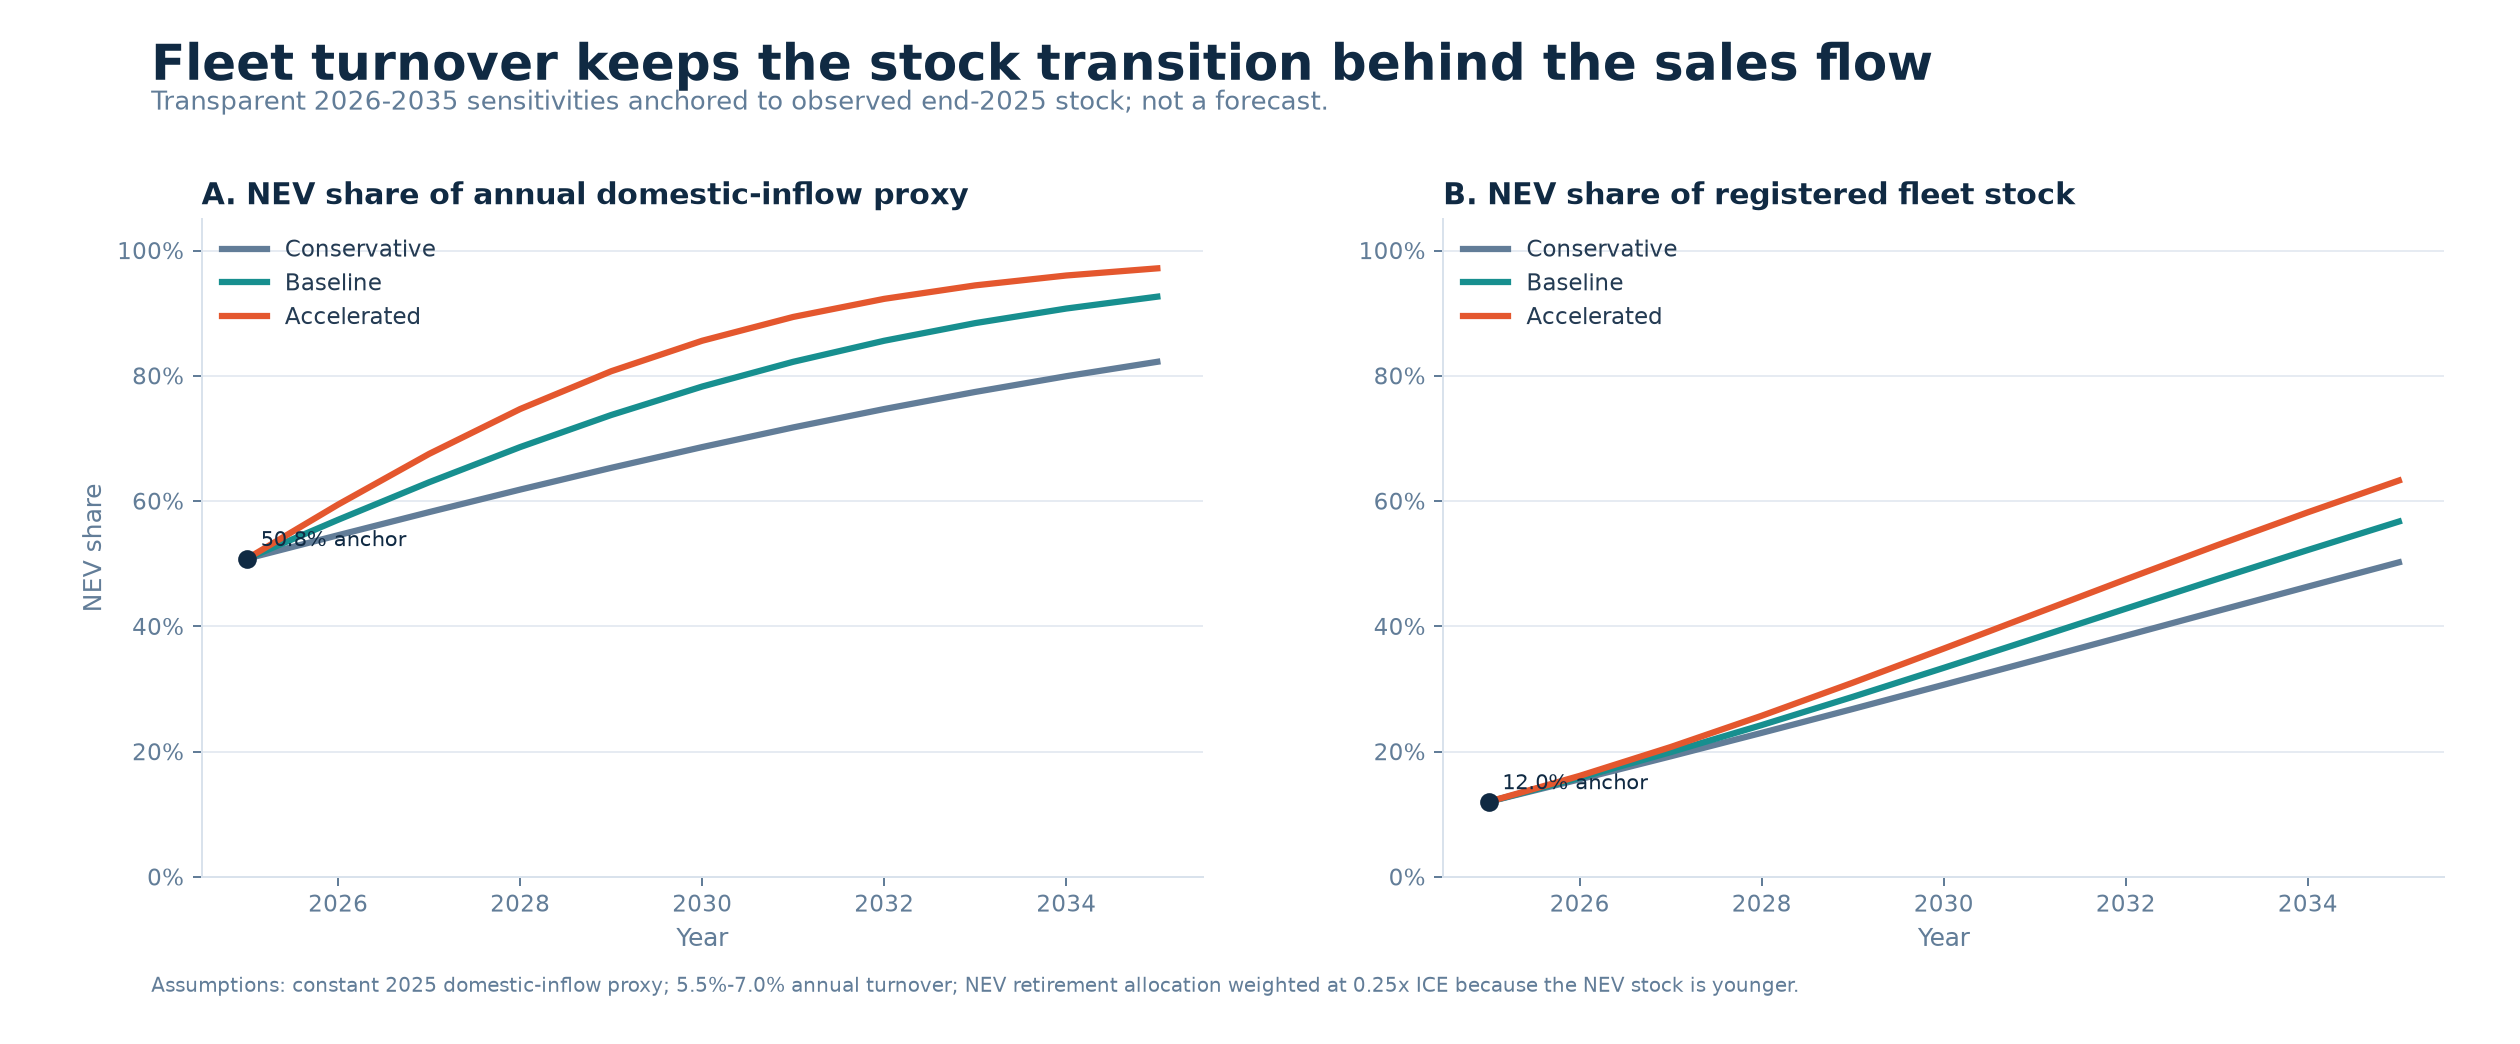

In [7]:
fleet_model = pd.read_csv(DATA / "fleet_turnover_scenarios.csv")
backtest = pd.read_csv(DATA / "sales_share_backtest_2023_2025.csv")

endpoints = fleet_model.loc[
    fleet_model.year.isin([2030, 2035]),
    [
        "scenario",
        "year",
        "nev_inflow_share_pct",
        "nev_fleet_share_pct",
        "nev_stock_m",
        "total_auto_stock_m",
    ],
].copy()
display(endpoints.round(1))
display(backtest.round(2))
print(f"Held-out 2023-2025 MAE: {backtest.absolute_error_pp.mean():.2f} percentage points")
display(Image(filename=str(ROOT / "figures" / "fleet_turnover_scenarios.png"), width=1100))

## 6. Limits and audit status

- The independent second-entry audit passed all 12 pre-2021 values.
- Archived evidence notes are pinned by SHA-256 checksums.
- NEA changed its charging statistical scope in 2025; incompatible
  endpoints are not used to calculate a spurious growth rate.
- The powertrain composition series stops at 2024 because a consistent
  independently verifiable 2025 split was not established.
- Sales, exports, registrations, fleet stock, and scenario output remain
  separate statistical concepts.
- The sales-share paths and fleet outputs are transparent sensitivities;
  they are not probabilities, causal estimates, or registration forecasts.